# PSTHs and rasters for the belief/stimulus example units

The single-unit figure panels for the A/B/C group comparison, at `FeedbackOnsetLong`. One figure per
unit: mean firing rate for the three groups on top, the spike raster those means come from
underneath, in the two-row layout `visualization_utils.plot_psth_both_events` uses for the
choice/preference panels elsewhere in the paper.

Relative to a feature X, over correct trials:

```
A: X not chosen, X not preferred     B: X chosen, X not preferred     C: X chosen, X preferred
        \________ Run S ________/            \________ Run P ________/
         the stimulus contrast                  the belief contrast
```

so **A vs B is the stimulus step and B vs C the belief step**. The units listed below are hand-picked
from `20260824_ordered_coselective_units.ipynb` -- items co-selective in both runs *and* ordered
(the two steps point the same way) in all 5 bins of their flagged window. Their p-values and steps
are printed with the table below rather than drawn on the figures, following
`20260820_coselective_example_units.ipynb`: these are the most extreme items out of ~109k, chosen
because they are extreme, so a single PSTH is an illustration and not evidence.

Two things to know when reading a panel:

- `SHOW_TITLE` and `SHOW_LEGEND` turn the identity line and the group key on and off. Both default
  to on, which is what makes a panel readable on its own here; off is the figure as it goes into a
  multi-panel layout, where the caption carries that text and the margins they occupied are given
  back to the axes.
- The **PSTH uses every trial** in each group; the **raster is subsampled to a balanced number per
  group** (`RASTER_TRIALS_PER_GROUP`), because A typically has 4-6x the trials of B and C and an
  unbalanced raster squashes the two chosen groups into thin bands. The `n =` in each title is the
  PSTH's counts; the raster's per-group count is printed alongside.

Figures are written as svg to `/data/patrick_res/figures/wcst_paper/belief_stim_single_units/`.

In [9]:
%load_ext autoreload
%autoreload 2

import argparse
import os
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.behavioral_utils as behavioral_utils
import utils.io_utils as io_utils
import utils.visualization_utils as visualization_utils

from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.anova_analysis.stim_belief_unit_overlap import OUTPUT_PATH, ALPHA
from scripts.pseudo_decoding.belief_partitions.stim_belief_vector_alignment import (
    prep_behavior_for_feat, group_masks, BASE_GROUPS,
)

plt.rcParams.update({"font.size": 16})

# only feedback here: the stimulus-aligned item table for this analysis has not been run, and the
# groups are defined by what was chosen and believed on the trial, which the feedback epoch carries
TRIAL_EVENT = "FeedbackOnsetLong"

FIG_PATH = "/data/patrick_res/figures/wcst_paper/belief_stim_single_units"

# A -> B is the stimulus step and B -> C the belief step, so B and C take the colours the repo
# already uses for those two variables and A is the neutral starting point. Same as the two
# example-unit notebooks these figures come from
GROUP_TO_COLOR = {
    "A": "grey",
    "B": visualization_utils.MODE_TO_COLOR["feature"],
    "C": visualization_utils.MODE_TO_COLOR["preference"],
}
GROUP_TO_LABEL = {
    "A": "A: not selected, not pref.",
    "B": "B: selected, not pref.",
    "C": "C: selected, pref.",
}

FB_TICKS = [-1.5, -1, -.5, 0, .5, 1, 1.5]

# what the panel carries besides the data. Defaults on, so a figure read here identifies itself;
# turn them off for a panel going into a composed figure whose caption says the same things. The
# axes take back the margin either one was occupying, so a stripped panel is bigger, not emptier
SHOW_TITLE = True
SHOW_LEGEND = True

# trials per group in the raster. "balanced" is the smallest group's size, which is what keeps the
# three colour bands comparable in height; an int caps every group at that many; None draws every
# trial, which is what the PSTH above it always uses
RASTER_TRIALS_PER_GROUP = "balanced"
RASTER_SEED = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## The units

Hand-picked, not searched for here -- the search is `20260824_ordered_coselective_units.ipynb`, and
copying its output into a list is what makes this notebook a figure generator rather than a second
copy of the analysis. Each entry is a `(unit, X)` pair -- everything a panel needs, since it spans
the whole epoch -- and the animal and region are looked up from the item table so the figures and
the analysis cannot drift apart on which unit is where.

The p-values printed alongside are the pair's **strongest window**, `max(p_s, p_p)` minimised over
the windows the ANOVA ran. They are context for why the unit is in the list, not what put it there;
the search is `20260824_ordered_coselective_units.ipynb`, and nothing about the window reaches the
figure.

In [10]:
# (PseudoUnitID, feature X). All five are co-selective and ordered in all 5 bins of some 500 ms
# window; the comment is the direction and the window they were flagged at, kept as provenance
EXAMPLE_UNITS = [
    (2018080611, "CIRCLE"),   
    (2018090724, "ESCHER"),  
    (2018092005, "ESCHER"),  
    (2018070936, "POLKADOT"),
    (2018092500, "GREEN"),
    (2018092819, "ESCHER"),
    (2018080123, "SQUARE"),
    (2018081708, "RIPPLE"),
]


def annotate_examples(units=EXAMPLE_UNITS, trial_event=TRIAL_EVENT):
    """
    Looks each (unit, X) pair up in the item table, so the panels carry the region and animal the
    analysis assigned them.

    A pair has one row per 500 ms window, and a panel spans all of them, so the rows are collapsed
    to one. Animal and region are properties of the unit and identical down those rows; the
    p-values are not, so the row kept is the pair's strongest window -- max(p_s, p_p) minimised,
    ties to the earliest -- and it is reported as context, not as what selected the unit.

    A missing pair would leave the notebook plotting four panels where five were asked for, so the
    lookup raises rather than dropping it.
    """
    items = pd.read_pickle(os.path.join(OUTPUT_PATH, f"{trial_event}_item_pvals.pickle"))
    asked = pd.DataFrame(units, columns=["PseudoUnitID", "feat"])
    merged = asked.merge(items, on=["PseudoUnitID", "feat"], how="left", validate="1:m")
    missing = merged[merged.subject.isna()]
    if len(missing):
        raise ValueError(f"not in the {trial_event} item table:\n"
                         f"{missing[asked.columns].to_string()}")

    merged["p_worse"] = merged[["p_s", "p_p"]].max(axis=1)
    best = merged.sort_values(["p_worse", "WindowStartMilli"]).drop_duplicates(["PseudoUnitID", "feat"])
    # that sort left the rows ordered by p_worse; merge back onto `asked` to restore the order
    # EXAMPLE_UNITS was written in, which is the order the panels come out in
    best = asked.merge(best, on=["PseudoUnitID", "feat"], how="left", validate="1:1")
    best = best.rename(columns={"WindowStartMilli": "best_window"})
    best["region"] = best.structure_level2_cleaned.map(
        lambda r: visualization_utils.REGION_TO_ABBREV.get(r, str(r).split("_")[-1]))
    return best


examples = annotate_examples()
display(examples[["PseudoUnitID", "feat", "subject", "region",
                  "best_window", "p_s", "p_p", "eta2_s", "eta2_p"]])

,PseudoUnitID,feat,subject,region,best_window,p_s,p_p,eta2_s,eta2_p
0,2018080611,CIRCLE,SA,LPFC,0,0.01,0.03,0.017972,0.051996
1,2018090724,ESCHER,SA,AMY,-900,0.01,0.01,0.302624,0.074260
2,2018092005,ESCHER,SA,ITC,-1300,0.29,0.26,0.003864,0.011798
3,2018070936,POLKADOT,SA,DSTR,-700,0.01,0.08,0.034853,0.023194
4,2018092500,GREEN,SA,ITC,-700,0.01,0.01,0.144222,0.075512
5,2018092819,ESCHER,SA,ITC,-900,0.01,0.01,0.091485,0.078951
6,2018080123,SQUARE,SA,LPFC,-1100,0.07,0.19,0.009931,0.012606
7,2018081708,RIPPLE,SA,HC,-100,0.01,0.02,0.165481,0.062843


## The figure

`plot_unit` is the panel: `sns.lineplot` over the three groups on the top axes and
`visualization_utils.visualize_unit_raster` -- the same raster the choice/preference figures use --
on the bottom, sharing an x axis, at the 1:2 height ratio and with the dotted event markers of
`plot_psth_both_events`.

The raster function keys its colours off a column called `condition`, so `group` is copied into it;
that is the only adaptation. Both axes are laid out with an explicit `gridspec_kw` rather than
`tight_layout`, because a legend outside the axes makes `tight_layout` shrink the top row alone and
the two x axes then stop lining up. That layout is also where the two toggles do their work: the
right margin is only reserved when there is a legend to put in it, and the top margin only when
there is a title.

In [13]:
def load_unit_trials(unit_id, feat, trial_event=TRIAL_EVENT):
    """
    One unit's trial-by-trial firing rates and the behaviour they align to, both labelled A/B/C.

    The session is recoverable from the PseudoUnitID (`int(session) * 100 + UnitID`), so a row of
    the item table is enough to find the data. Groups come from stim_belief_vector_alignment rather
    than being redefined here -- that module is what the population analysis and the ANOVA runs both
    use, so these three cells are identical to theirs by construction.

    Returns the merged firing rates (for the PSTH), the group-labelled behaviour (for the raster,
    which needs the trial event times), and the identifiers both need.
    """
    session = str(unit_id // 100)
    subject = behavioral_utils.get_sub_for_session(session)

    args = argparse.Namespace(
        subject=subject, trial_event=trial_event, fr_type="firing_rates",
        trial_interval=get_trial_interval(trial_event), time_range=None,
    )
    beh = prep_behavior_for_feat(
        behavioral_utils.get_valid_belief_beh_for_sub_sess(subject, session), feat
    )
    masks = group_masks(beh)
    beh["group"] = np.select([masks[g] for g in BASE_GROUPS], BASE_GROUPS, default=None)
    beh = beh[beh.group.notna()].copy()
    # visualize_unit_raster colours and sorts on a column named `condition`
    beh["condition"] = beh.group

    frs = io_utils.get_frs_from_args(args, session)
    frs = frs[frs.PseudoUnitID == unit_id]
    psth = pd.merge(frs, beh[["TrialNumber", "group"]], on="TrialNumber")
    return psth, beh, subject, session, args.trial_interval


def subsample_raster_trials(beh, per_group=RASTER_TRIALS_PER_GROUP, seed=RASTER_SEED):
    """
    Equal trials per group for the raster. A runs 4-6x the size of B and C, so drawn in full it
    takes most of the vertical space and the two chosen groups become unreadable bands.

    Only the raster is subsampled -- the PSTH keeps every trial, where extra A trials cost nothing
    and buy a tighter error band.
    """
    if per_group is None:
        return beh
    n = beh.group.value_counts().min() if per_group == "balanced" else int(per_group)
    return beh.groupby("group", group_keys=False).apply(
        lambda g: g.sample(min(n, len(g)), random_state=seed))


def plot_unit(row, show_title=SHOW_TITLE, show_legend=SHOW_LEGEND):
    """One example unit: PSTH over the raster it is computed from, sharing an x axis."""
    psth, beh, subject, session, trial_interval = load_unit_trials(row.PseudoUnitID, row.feat)
    raster_beh = subsample_raster_trials(beh)

    # explicit margins instead of tight_layout: see the markdown above. `right` reserves the strip
    # the legend sits in, so both axes keep the same width and their x ticks stay aligned, and
    # neither margin is reserved when the thing it was for is switched off
    fig, (ax_psth, ax_rast) = plt.subplots(
        2, 1, figsize=(6, 6), sharex=True,
        gridspec_kw={"height_ratios": [1, 2], "hspace": 0.12, "left": 0.10, "bottom": 0.11,
                     "right": 0.64 if show_legend else 0.97,
                     "top": 0.86 if show_title else 0.97},
    )

    sns.lineplot(
        psth, x="Time", y="FiringRate", hue="group", hue_order=BASE_GROUPS,
        palette=GROUP_TO_COLOR, linewidth=3, errorbar="se", ax=ax_psth,
    )
    visualization_utils.visualize_unit_raster(
        subject, session, row.PseudoUnitID, raster_beh, trial_interval,
        ax=ax_rast, hue_order=BASE_GROUPS, palette=GROUP_TO_COLOR,
    )

    for ax in (ax_psth, ax_rast):
        # stimuli appear ~800 ms before feedback, and 0 is feedback itself
        ax.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
        ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    ax_psth.set_ylabel("Firing rate (Hz)")
    ax_rast.set_ylabel("Trials")
    ax_rast.set_ylim(-1, len(raster_beh))
    ax_rast.set_xlabel("Time to feedback (s)")
    ax_rast.set_xticks(FB_TICKS)
    ax_rast.set_xticklabels(FB_TICKS)
    # the raster's spikes run to the end of the post interval while the last firing rate bin starts
    # 100 ms short of it; clipping to the PSTH's range keeps the two rows on the same axis
    ax_rast.set_xlim(psth.Time.min(), psth.Time.max())

    if show_title:
        # identity and trial counts only -- the p-values that picked the unit are in the table above
        n_per_group = beh.group.value_counts()
        ax_psth.set_title(
            f"unit {int(row.PseudoUnitID)}  ({subject}, {row.region})  |  X = {row.feat}\n"
            f"n = {', '.join(f'{g}:{n_per_group.get(g, 0)}' for g in BASE_GROUPS)}"
            f"   (raster: {len(raster_beh) // len(BASE_GROUPS)} per group)",
            fontsize=12,
        )

    if show_legend:
        # built by hand rather than from the lineplot's handles: those carry the raw group letters,
        # and the raster contributes a second set of handles for the same three colours
        handles = [plt.Line2D([], [], color=GROUP_TO_COLOR[g], linewidth=6, label=GROUP_TO_LABEL[g])
                   for g in BASE_GROUPS]
        fig.legend(handles=handles, loc="center left", bbox_to_anchor=(0.66, 0.5),
                   frameon=False, fontsize=12)

    visualization_utils.format_plot([ax_psth, ax_rast])
    return fig


def fig_name(row):
    """Animal and region first so the directory sorts into something browsable; unit and feature
    are the whole identity of a panel."""
    return f"{row.subject}_{row.region}_{int(row.PseudoUnitID)}_{row.feat}"


## The panels

Drawn and written out. Read **A vs B for the stimulus step and B vs C for the belief step**: in
these five the two go the same way, so the three levels come out stacked, preference moving the rate
further in whatever direction selection already moved it.

`plot_unit` takes `show_title` / `show_legend` per call as well, so a stripped version of one panel
is `plot_unit(examples.iloc[0], show_title=False, show_legend=False)` without touching the defaults.
The file name doesn't record the toggles, so saving a stripped panel overwrites the annotated one.

/data/patrick_res/figures/wcst_paper/belief_stim_single_units/SA_LPFC_2018080611_CIRCLE
/data/patrick_res/figures/wcst_paper/belief_stim_single_units/SA_AMY_2018090724_ESCHER
/data/patrick_res/figures/wcst_paper/belief_stim_single_units/SA_ITC_2018092005_ESCHER
/data/patrick_res/figures/wcst_paper/belief_stim_single_units/SA_DSTR_2018070936_POLKADOT
/data/patrick_res/figures/wcst_paper/belief_stim_single_units/SA_ITC_2018092500_GREEN
/data/patrick_res/figures/wcst_paper/belief_stim_single_units/SA_ITC_2018092819_ESCHER
/data/patrick_res/figures/wcst_paper/belief_stim_single_units/SA_LPFC_2018080123_SQUARE
/data/patrick_res/figures/wcst_paper/belief_stim_single_units/SA_HC_2018081708_RIPPLE


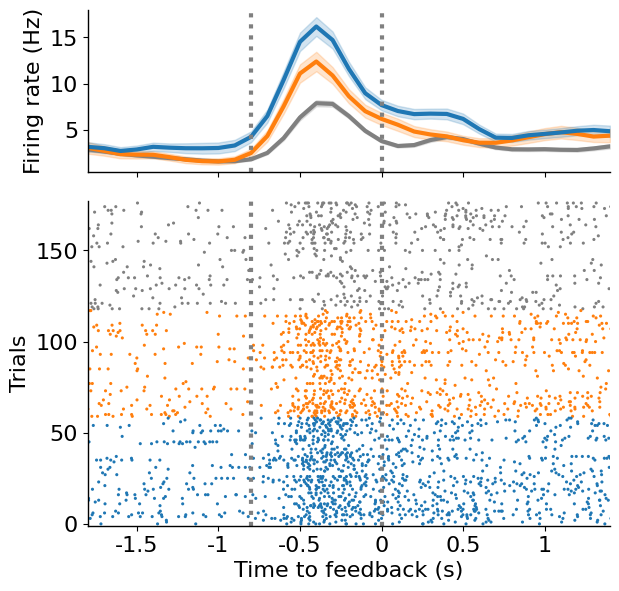

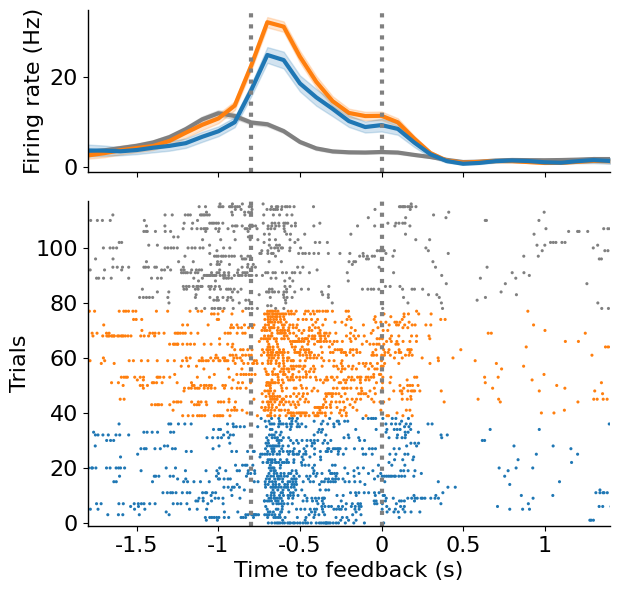

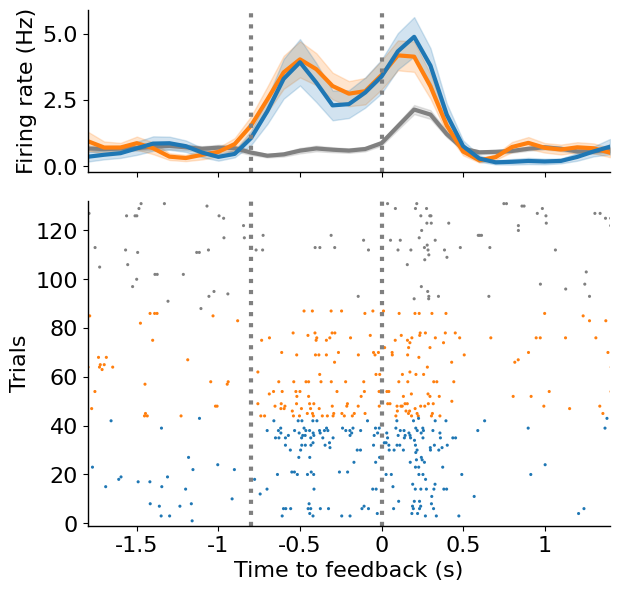

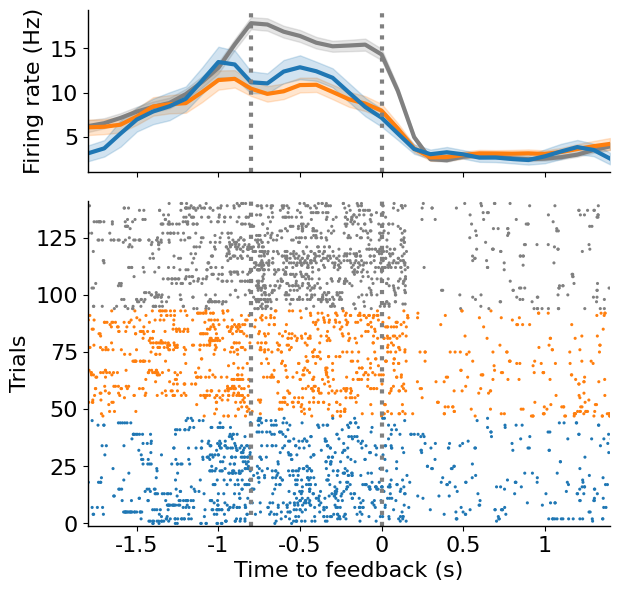

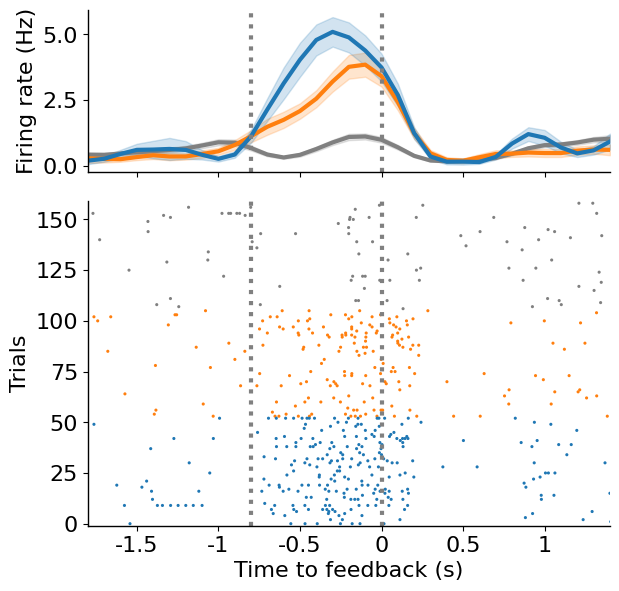

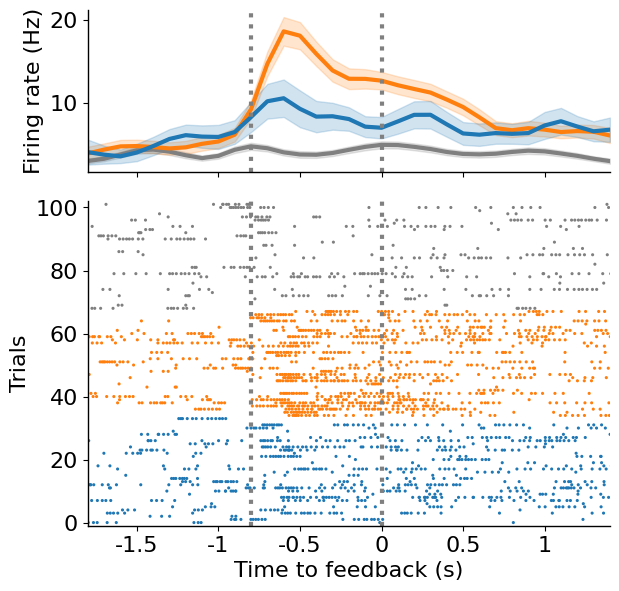

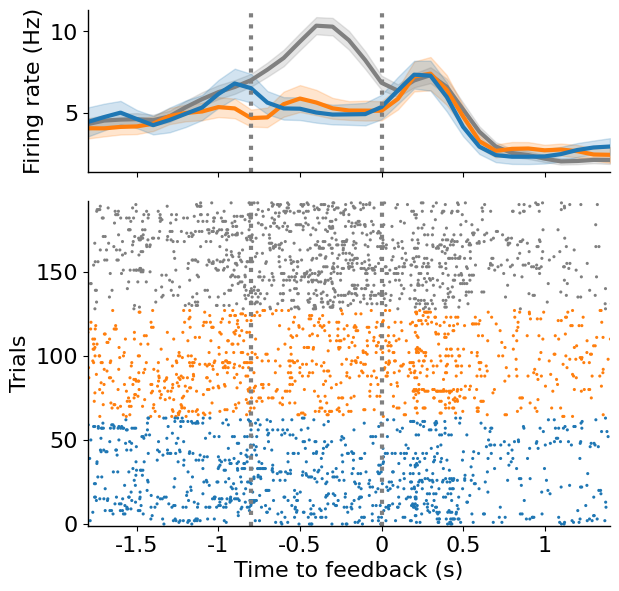

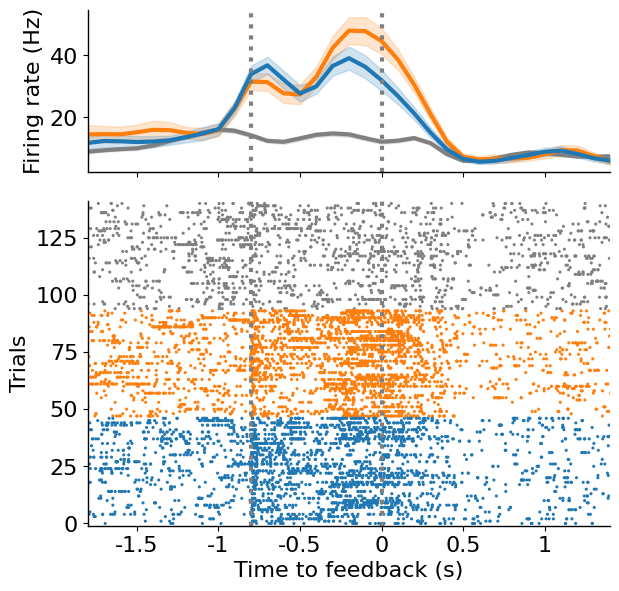

In [14]:
os.makedirs(FIG_PATH, exist_ok=True)

figs = []
for _, row in examples.iterrows():
    fig = plot_unit(row, show_title=False, show_legend=False)
    path = os.path.join(FIG_PATH, fig_name(row))
    fig.savefig(f"{path}.svg")
    fig.savefig(f"{path}.png", dpi=300)
    print(path)
    figs.append(fig)